# 04 — Final Figures

Publication-quality figures for the project report.

- Runtime scaling (serial vs parallel)
- Speedup curve
- Assignment rank distribution (mean over 100 MC trials)
- First-choice rate histogram

All figures are saved to `results/figures/`.

In [29]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

include("../src/types.jl")
include("../src/generate_data.jl")
include("../src/serial_sim.jl")
include("../src/parallel_sim.jl")
include("../src/monte_carlo.jl")
include("../src/benchmarks.jl")
include("../src/plots.jl")

using Plots
println("Julia threads: ", Threads.nthreads())

  Activating project at `~/Documents/MIT/18.337/parallel-school-assignment-sim`


Julia threads: 8


In [30]:
students, schools = generate_scenario(; seed = 42, base_capacity = 300)

(Student[Student(1, [17, 2, 20, 13, 15], 0.5776180399036042), Student(2, [20, 15, 2, 18, 13], 0.42108744744559745), Student(3, [7, 20, 6, 13, 1], 0.1189646291016957), Student(4, [11, 16, 18, 10, 4], 0.5084067760768716), Student(5, [1, 11, 14, 20, 5], 0.06789763512912672), Student(6, [1, 13, 10, 5, 16], 0.4272368880629398), Student(7, [13, 2, 10, 18, 14], 0.25466424071119564), Student(8, [13, 2, 17, 3, 12], 0.5569127441511577), Student(9, [18, 19, 20, 9, 17], 0.3414258240267456), Student(10, [13, 5, 2, 4, 7], 0.7067411881639054)  …  Student(9991, [3, 18, 7, 11, 20], 0.9558741362169305), Student(9992, [20, 7, 2, 4, 13], 0.5953170920809927), Student(9993, [19, 6, 11, 15, 20], 0.5921289844392843), Student(9994, [10, 20, 7, 16, 2], 0.71127422924206), Student(9995, [18, 7, 16, 6, 2], 0.7493663962591), Student(9996, [16, 6, 13, 15, 2], 0.6234351111983603), Student(9997, [11, 13, 17, 4, 20], 0.6666049133687935), Student(9998, [10, 14, 17, 13, 11], 0.3971050817557533), Student(9999, [19, 14, 5,

## 1. Scaling Data

In [31]:
trial_counts, serial_times, parallel_times = scaling_experiment(
    students, schools;
    trial_counts = [10, 25, 50, 100, 200],
    n_samples    = 5,
)

  n_trials = 10
  n_trials = 25
  n_trials = 50
  n_trials = 100
  n_trials = 200


([10, 25, 50, 100, 200], [10.902292, 26.00125, 48.1125, 122.068917, 237.347667], [3.027166, 5.849875, 10.383, 23.64425, 33.905042])

## 2. Monte Carlo Aggregation (100 trials)

In [32]:
summaries = run_monte_carlo(students, schools, 100; parallel = true, seed = 42)
agg = aggregate_results(summaries)
print_summary(agg)

Monte Carlo Summary  (100 trials)
  Mean first-choice rate : 48.24%  (±0.30%)
  Mean unassigned        : 3963.0  (±0.0)
  Rank distribution (mean fraction):
    Rank 1 : 48.24%
    Rank 2 : 5.69%
    Rank 3 : 2.83%
    Rank 4 : 1.96%
    Rank 5 : 1.65%


## 3. Generate and Save All Figures

In [33]:
save_all_figures(
    trial_counts, serial_times, parallel_times, summaries, agg;
    dir = "../results/figures",
)

Figures saved to ../results/figures/


## 4. Inline Preview

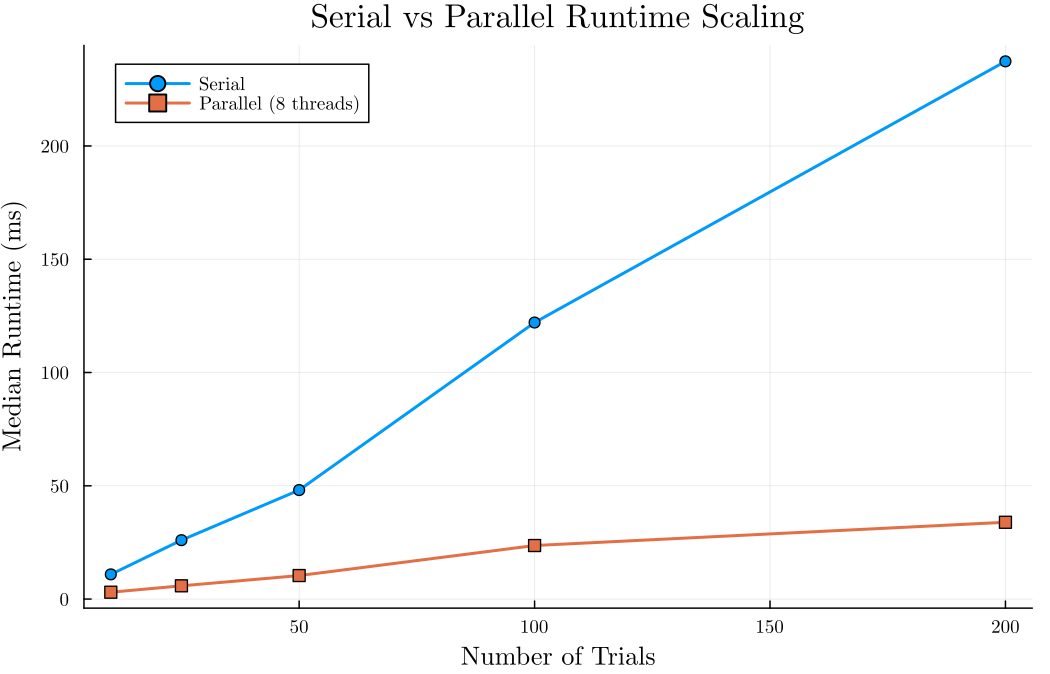

In [34]:
plot_scaling(trial_counts, serial_times, parallel_times)

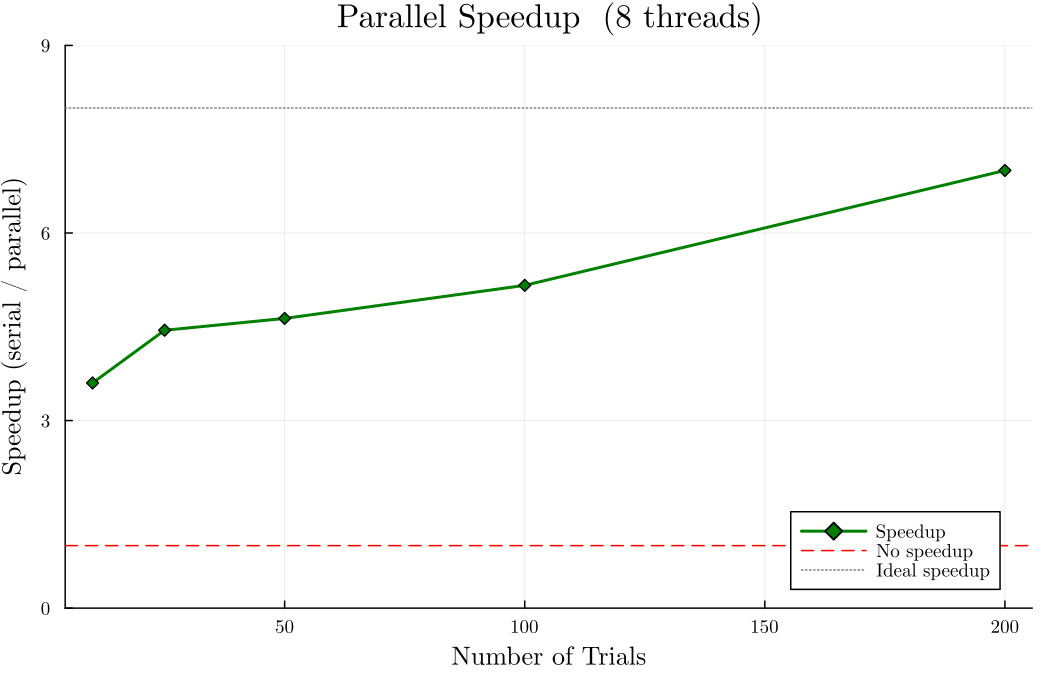

In [35]:
plot_speedup(trial_counts, serial_times, parallel_times)

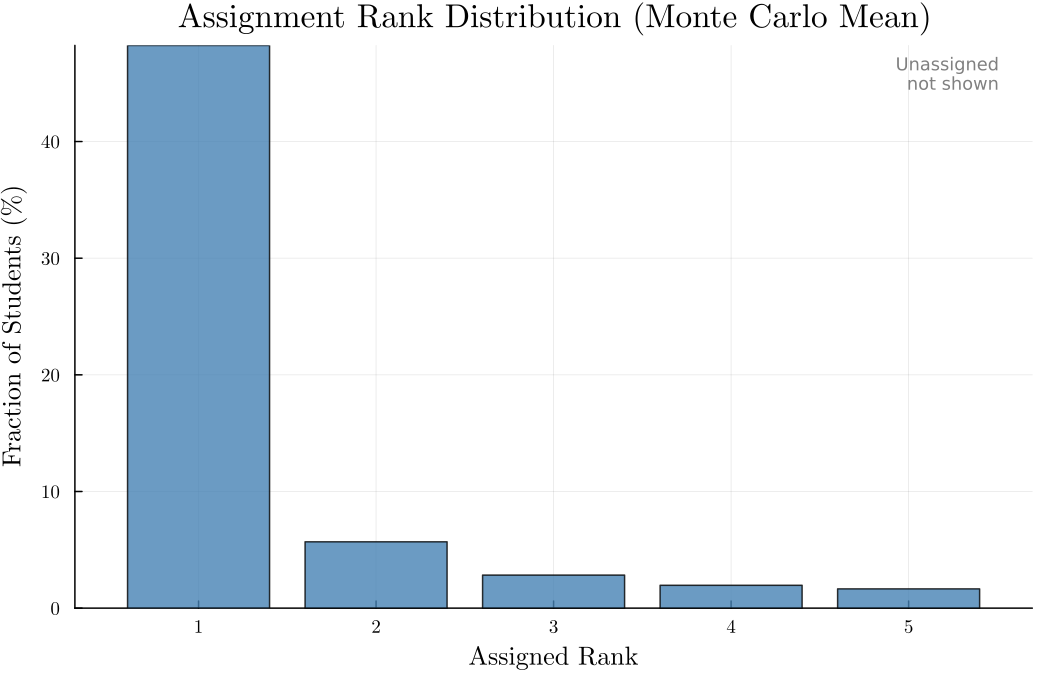

In [36]:
plot_rank_distribution(agg.mean_rank_distribution)

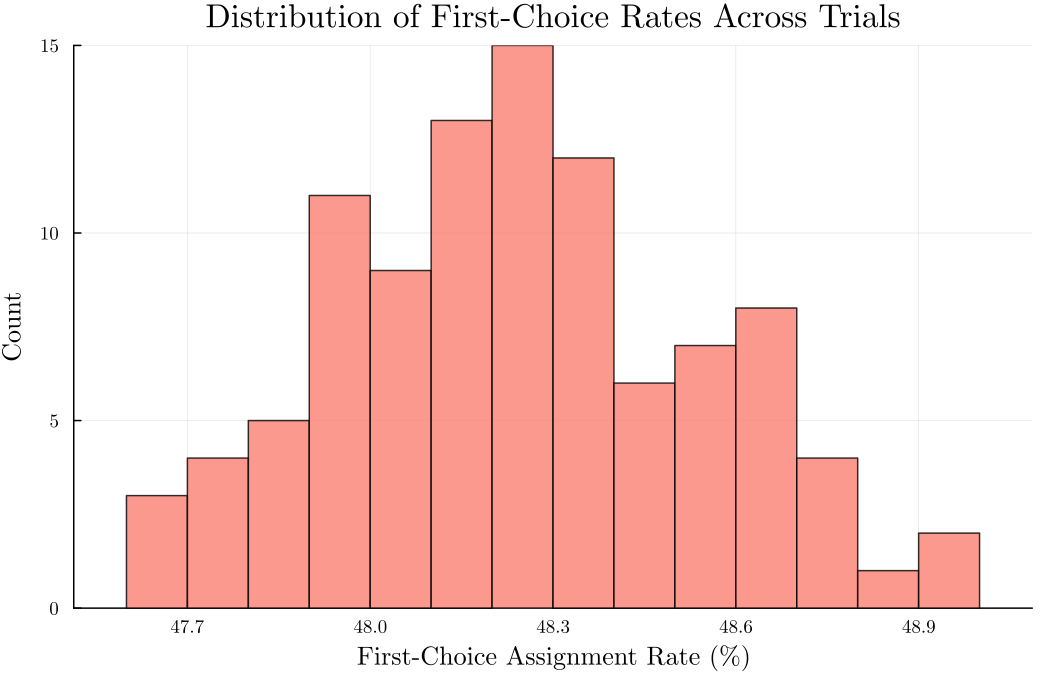

In [37]:
plot_first_choice_distribution(summaries)